In [39]:
import netCDF4 as ncdf
import numpy as np
import matplotlib.pyplot as plt

In [40]:
fnames_in=[];labels=[]
fnames_in.append("../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m1_10.nc");labels.append("Modes 1-10")
fnames_in.append("../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m1.nc");labels.append("Modes 1")
fnames_in.append("../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m2.nc");labels.append("Modes 2")
fnames_in.append("../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m3_5.nc");labels.append("Modes 3-5")
fnames_in.append("../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m6_10.nc");labels.append("Modes 6-10")


../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m1_10.nc
../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m1.nc
../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m2.nc
../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m3_5.nc
../OUTPUTS/avg_zlev_eqpac30_jra55do_mode10_unicp_m6_10.nc


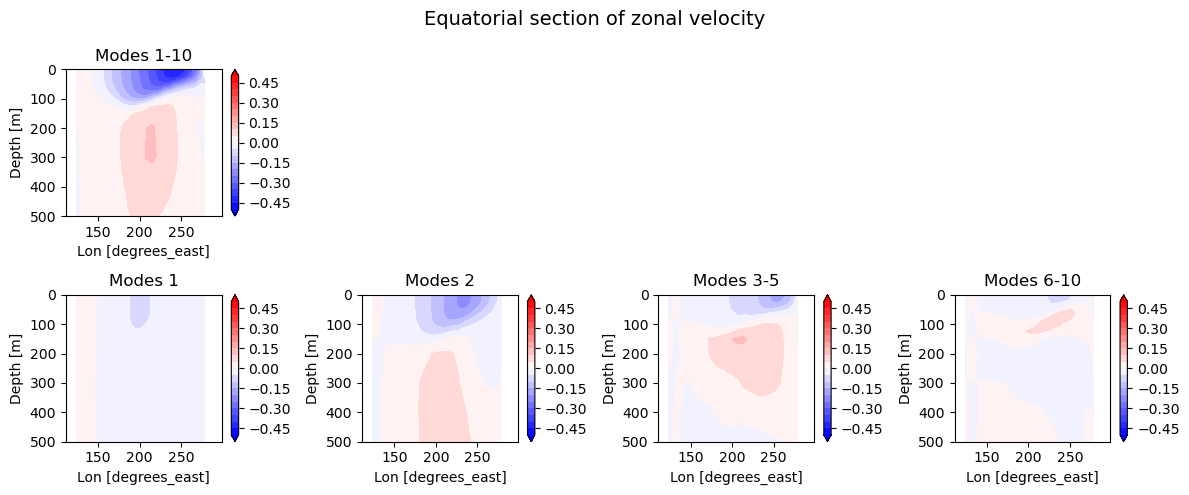

In [44]:
nfile=len(fnames_in)
#nfile=1
lat1=-5;lat2=5
lev1=0;lev2=500
fname_fig="figure_eqsec_eqpac30_mode10.png"
figure=plt.figure(figsize=(12,5))
clevs=np.linspace(-0.5,0.5,21)
for ifile in range(0,nfile):
    nc_in=ncdf.Dataset(fnames_in[ifile],"r")
    u=nc_in.variables["u"][:]
    lon=nc_in.variables["lon"][:]
    lat=nc_in.variables["lat"][:]
    lev=nc_in.variables["lev"][:]
    ilat=np.where((lat>=lat1) & (lat <= lat2))[0]
    ilev=np.where((lev>=lev1) & (lev <= lev2))[0]
    lev_cut=lev[ilev]
    u_cut=np.nanmean(np.nanmean(u[:,:,ilat,:],axis=2),axis=0)
    if (ifile==1):
        u_sum=np.copy(u_cut)

    if (ifile >1):
        u_sum=u_sum+u_cut        
    x,y=np.meshgrid(lon,lev_cut)
    if (ifile==0):
        iplot=1
    else:
        iplot=3+ifile+1
    print(fnames_in[ifile])
    plt.subplot(2,4,iplot)
    plt.contourf(x,y,u_cut,cmap="bwr",extend="both",levels=clevs)
    plt.ylim([lev2,lev1])
    plt.title(labels[ifile])
    plt.xlabel("Lon [degrees_east]")
    plt.ylabel("Depth [m]")
    plt.colorbar()
    nc_in.close()
figure.suptitle('Equatorial section of zonal velocity',fontsize=14)
plt.tight_layout()
plt.savefig(fname_fig)

